# Libraries and Functions

In [1]:
#Importing libraries
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
pd.options.display.max_rows = 999
import warnings
warnings.filterwarnings("ignore")
import sys
sys.dont_write_bytecode = True
#importing datasets
from src.New_Utils import New_Sequences
from Datasets import Replace
from Datasets import AIDE
from Datasets import Shanghai
#Libraries to run the experiments
from src.model import Model
from sklearn.model_selection import StratifiedKFold
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

In [13]:
Model = Model()

In [17]:
def Run_Models(sequences, l1_penalty, l2_penalty, learning_rate, batch_size,  skf, Model):

    model = Model
    results = []

    # loop across the folds
    for i, (train_index, test_index) in enumerate(skf.split(X=[s['X'] for s in sequences], y=[s['Y'] for s in sequences])):
        
        # fit the model to the training set


        model.fit(
            sequences=[sequences[i] for i in train_index],
            sequence_length=int(7 * 24 * 60 // 5),
            l1_penalty=l1_penalty,
            l2_penalty=l2_penalty,
            learning_rate=learning_rate,
            batch_size=batch_size,
            epochs=1000,
            seed=42,
            verbose=0
        )

        # evaluate the model on the test set
        metrics = model.evaluate(sequences=[sequences[i] for i in test_index])

        # save the results
        results.append(metrics)

    # organize the results in a data frame
    results = pd.DataFrame(results)

    return results.mean().values[6]

# Grid Search

In [5]:
Parameters =[[0.01, 0.01, 1e-06, 64]
,[0.01, 0.01, 1e-06, 32]
,[0.01, 0.01, 1e-06, 16]
,[0.01, 0.01, 1e-06, 128]
,[0.01, 0.01, 0.1, 64]
,[0.01, 0.01, 0.1, 32]
,[0.01, 0.01, 0.1, 16]
,[0.01, 0.01, 0.1, 128]
,[0.01, 0.01, 0.0001, 64]
,[0.01, 0.01, 0.0001, 32]
,[0.01, 0.01, 0.0001, 16]
,[0.01, 0.01, 0.0001, 128]
,[0.01, 0.001, 1e-06, 64]
,[0.01, 0.001, 1e-06, 32]
,[0.01, 0.001, 1e-06, 16]
,[0.01, 0.001, 1e-06, 128]
,[0.01, 0.001, 0.1, 64]
,[0.01, 0.001, 0.1, 32]
,[0.01, 0.001, 0.1, 16]
,[0.01, 0.001, 0.1, 128]
,[0.01, 0.001, 0.0001, 64]
,[0.01, 0.001, 0.0001, 32]
,[0.01, 0.001, 0.0001, 16]
,[0.01, 0.001, 0.0001, 128]
,[0.01, 0.0001, 1e-06, 64]
,[0.01, 0.0001, 1e-06, 32]
,[0.01, 0.0001, 1e-06, 16]
,[0.01, 0.0001, 1e-06, 128]
,[0.01, 0.0001, 0.1, 64]
,[0.01, 0.0001, 0.1, 32]
,[0.01, 0.0001, 0.1, 16]
,[0.01, 0.0001, 0.1, 128]
,[0.01, 0.0001, 0.0001, 64]
,[0.01, 0.0001, 0.0001, 32]
,[0.01, 0.0001, 0.0001, 16]
,[0.01, 0.0001, 0.0001, 128]
,[0.001, 0.01, 1e-06, 64]
,[0.001, 0.01, 1e-06, 32]
,[0.001, 0.01, 1e-06, 16]
,[0.001, 0.01, 1e-06, 128]
,[0.001, 0.01, 0.1, 64]
,[0.001, 0.01, 0.1, 32]
,[0.001, 0.01, 0.1, 16]
,[0.001, 0.01, 0.1, 128]
,[0.001, 0.01, 0.0001, 64]
,[0.001, 0.01, 0.0001, 32]
,[0.001, 0.01, 0.0001, 16]
,[0.001, 0.01, 0.0001, 128]
,[0.001, 0.001, 1e-06, 64]
,[0.001, 0.001, 1e-06, 32]
,[0.001, 0.001, 1e-06, 16]
,[0.001, 0.001, 1e-06, 128]
,[0.001, 0.001, 0.1, 64]
,[0.001, 0.001, 0.1, 32]
,[0.001, 0.001, 0.1, 16]
,[0.001, 0.001, 0.1, 128]
,[0.001, 0.001, 0.0001, 64]
,[0.001, 0.001, 0.0001, 32]
,[0.001, 0.001, 0.0001, 16]
,[0.001, 0.001, 0.0001, 128]
,[0.001, 0.0001, 1e-06, 64]
,[0.001, 0.0001, 1e-06, 32]
,[0.001, 0.0001, 1e-06, 16]
,[0.001, 0.0001, 1e-06, 128]
,[0.001, 0.0001, 0.1, 64]
,[0.001, 0.0001, 0.1, 32]
,[0.001, 0.0001, 0.1, 16]
,[0.001, 0.0001, 0.1, 128]
,[0.001, 0.0001, 0.0001, 64]
,[0.001, 0.0001, 0.0001, 32]
,[0.001, 0.0001, 0.0001, 16]
,[0.001, 0.0001, 0.0001, 128]
,[0.0001, 0.01, 1e-06, 64]
,[0.0001, 0.01, 1e-06, 32]
,[0.0001, 0.01, 1e-06, 16]
,[0.0001, 0.01, 1e-06, 128]
,[0.0001, 0.01, 0.1, 64]
,[0.0001, 0.01, 0.1, 32]
,[0.0001, 0.01, 0.1, 16]
,[0.0001, 0.01, 0.1, 128]
,[0.0001, 0.01, 0.0001, 64]
,[0.0001, 0.01, 0.0001, 32]
,[0.0001, 0.01, 0.0001, 16]
,[0.0001, 0.01, 0.0001, 128]
,[0.0001, 0.001, 1e-06, 64]
,[0.0001, 0.001, 1e-06, 32]
,[0.0001, 0.001, 1e-06, 16]
,[0.0001, 0.001, 1e-06, 128]
,[0.0001, 0.001, 0.1, 64]
,[0.0001, 0.001, 0.1, 32]
,[0.0001, 0.001, 0.1, 16]
,[0.0001, 0.001, 0.1, 128]
,[0.0001, 0.001, 0.0001, 64]
,[0.0001, 0.001, 0.0001, 32]
,[0.0001, 0.001, 0.0001, 16]
,[0.0001, 0.001, 0.0001, 128]
,[0.0001, 0.0001, 1e-06, 64]
,[0.0001, 0.0001, 1e-06, 32]
,[0.0001, 0.0001, 1e-06, 16]
,[0.0001, 0.0001, 1e-06, 128]
,[0.0001, 0.0001, 0.1, 64]
,[0.0001, 0.0001, 0.1, 32]
,[0.0001, 0.0001, 0.1, 16]
,[0.0001, 0.0001, 0.1, 128]
,[0.0001, 0.0001, 0.0001, 64]
,[0.0001, 0.0001, 0.0001, 32]
,[0.0001, 0.0001, 0.0001, 16]
,[0.0001, 0.0001, 0.0001, 128]
]

## Replace

In [ ]:
sequences = New_Sequences(Replace)
Grid_Search_Results = pd.DataFrame(columns=['Parameters','AUC'])
for params in Parameters:
    l1_penalty, l2_penalty, learning_rate, batch_size = params
    try:
        R = Run_Models(sequences, l1_penalty,l2_penalty,learning_rate,batch_size, skf, Model)
        Grid_Search_Results = pd.concat([Grid_Search_Results, pd.DataFrame({
            'Parameters': [str(params)], 
            'AUC': [R]
        })], ignore_index=True)
    except Exception as e:
        print(f"Error con parámetros {params}: {e}")
        continue
Grid_Search_Results.sort_values(by='AUC', ascending=False)

## AIDE

In [ ]:
sequences = New_Sequences(AIDE)
Grid_Search_Results = pd.DataFrame(columns=['Parameters','AUC'])
for params in Parameters:
    l1_penalty, l2_penalty, learning_rate, batch_size = params
    try:
        R = Run_Models(sequences, l1_penalty,l2_penalty,learning_rate,batch_size, skf, Model)
        Grid_Search_Results = pd.concat([Grid_Search_Results, pd.DataFrame({
            'Parameters': [str(params)], 
            'AUC': [R]
        })], ignore_index=True)
    except Exception as e:
        print(f"Error con parámetros {params}: {e}")
        continue
Grid_Search_Results.sort_values(by='AUC', ascending=False)

Error con parámetros [0.01, 0.01, 1e-06, 64]: Model.fit() missing 1 required positional argument: 'self'
Error con parámetros [0.01, 0.01, 1e-06, 32]: Model.fit() missing 1 required positional argument: 'self'
Error con parámetros [0.01, 0.01, 1e-06, 16]: Model.fit() missing 1 required positional argument: 'self'
Error con parámetros [0.01, 0.01, 1e-06, 128]: Model.fit() missing 1 required positional argument: 'self'
Error con parámetros [0.01, 0.01, 0.1, 64]: Model.fit() missing 1 required positional argument: 'self'
Error con parámetros [0.01, 0.01, 0.1, 32]: Model.fit() missing 1 required positional argument: 'self'
Error con parámetros [0.01, 0.01, 0.1, 16]: Model.fit() missing 1 required positional argument: 'self'
Error con parámetros [0.01, 0.01, 0.1, 128]: Model.fit() missing 1 required positional argument: 'self'
Error con parámetros [0.01, 0.01, 0.0001, 64]: Model.fit() missing 1 required positional argument: 'self'
Error con parámetros [0.01, 0.01, 0.0001, 32]: Model.fit() m

,Parameters,AUC


# Shanghai

In [21]:
sequences = New_Sequences(Shanghai, minutes=15)
Grid_Search_Results = pd.DataFrame(columns=['Parameters','AUC'])
for params in Parameters:
    l1_penalty, l2_penalty, learning_rate, batch_size = params
    try:
        R = Run_Models(sequences, l1_penalty,l2_penalty,learning_rate,batch_size, skf, Model)
        Grid_Search_Results = pd.concat([Grid_Search_Results, pd.DataFrame({
            'Parameters': [str(params)], 
            'AUC': [R]
        })], ignore_index=True)
    except Exception as e:
        print(f"Error con parámetros {params}: {e}")
        continue
Grid_Search_Results.sort_values(by='AUC', ascending=False)

,Parameters,AUC
102,"[0.0001, 0.0001, 0.1, 16]",0.75
54,"[0.001, 0.001, 0.1, 16]",0.714286
66,"[0.001, 0.0001, 0.1, 16]",0.702381
7,"[0.01, 0.01, 0.1, 128]",0.690476
4,"[0.01, 0.01, 0.1, 64]",0.690476
5,"[0.01, 0.01, 0.1, 32]",0.690476
42,"[0.001, 0.01, 0.1, 16]",0.613095
67,"[0.001, 0.0001, 0.1, 128]",0.607143
64,"[0.001, 0.0001, 0.1, 64]",0.607143
65,"[0.001, 0.0001, 0.1, 32]",0.607143


# Random Search

In [22]:
Parameter = [[0.9447, 0.7984, 0.9425, 64]
,[0.9447, 0.7984, 0.9425, 32]
,[0.9447, 0.7984, 0.9425, 16]
,[0.9447, 0.7984, 0.9425, 128]
,[0.9447, 0.7984, 0.3126, 64]
,[0.9447, 0.7984, 0.3126, 32]
,[0.9447, 0.7984, 0.3126, 16]
,[0.9447, 0.7984, 0.3126, 128]
,[0.9447, 0.7984, 0.0916, 64]
,[0.9447, 0.7984, 0.0916, 32]
,[0.9447, 0.7984, 0.0916, 16]
,[0.9447, 0.7984, 0.0916, 128]
,[0.9447, 0.5364, 0.9425, 64]
,[0.9447, 0.5364, 0.9425, 32]
,[0.9447, 0.5364, 0.9425, 16]
,[0.9447, 0.5364, 0.9425, 128]
,[0.9447, 0.5364, 0.3126, 64]
,[0.9447, 0.5364, 0.3126, 32]
,[0.9447, 0.5364, 0.3126, 16]
,[0.9447, 0.5364, 0.3126, 128]
,[0.9447, 0.5364, 0.0916, 64]
,[0.9447, 0.5364, 0.0916, 32]
,[0.9447, 0.5364, 0.0916, 16]
,[0.9447, 0.5364, 0.0916, 128]
,[0.9447, 0.5143, 0.9425, 64]
,[0.9447, 0.5143, 0.9425, 32]
,[0.9447, 0.5143, 0.9425, 16]
,[0.9447, 0.5143, 0.9425, 128]
,[0.9447, 0.5143, 0.3126, 64]
,[0.9447, 0.5143, 0.3126, 32]
,[0.9447, 0.5143, 0.3126, 16]
,[0.9447, 0.5143, 0.3126, 128]
,[0.9447, 0.5143, 0.0916, 64]
,[0.9447, 0.5143, 0.0916, 32]
,[0.9447, 0.5143, 0.0916, 16]
,[0.9447, 0.5143, 0.0916, 128]
,[0.6265, 0.7984, 0.9425, 64]
,[0.6265, 0.7984, 0.9425, 32]
,[0.6265, 0.7984, 0.9425, 16]
,[0.6265, 0.7984, 0.9425, 128]
,[0.6265, 0.7984, 0.3126, 64]
,[0.6265, 0.7984, 0.3126, 32]
,[0.6265, 0.7984, 0.3126, 16]
,[0.6265, 0.7984, 0.3126, 128]
,[0.6265, 0.7984, 0.0916, 64]
,[0.6265, 0.7984, 0.0916, 32]
,[0.6265, 0.7984, 0.0916, 16]
,[0.6265, 0.7984, 0.0916, 128]
,[0.6265, 0.5364, 0.9425, 64]
,[0.6265, 0.5364, 0.9425, 32]
,[0.6265, 0.5364, 0.9425, 16]
,[0.6265, 0.5364, 0.9425, 128]
,[0.6265, 0.5364, 0.3126, 64]
,[0.6265, 0.5364, 0.3126, 32]
,[0.6265, 0.5364, 0.3126, 16]
,[0.6265, 0.5364, 0.3126, 128]
,[0.6265, 0.5364, 0.0916, 64]
,[0.6265, 0.5364, 0.0916, 32]
,[0.6265, 0.5364, 0.0916, 16]
,[0.6265, 0.5364, 0.0916, 128]
,[0.6265, 0.5143, 0.9425, 64]
,[0.6265, 0.5143, 0.9425, 32]
,[0.6265, 0.5143, 0.9425, 16]
,[0.6265, 0.5143, 0.9425, 128]
,[0.6265, 0.5143, 0.3126, 64]
,[0.6265, 0.5143, 0.3126, 32]
,[0.6265, 0.5143, 0.3126, 16]
,[0.6265, 0.5143, 0.3126, 128]
,[0.6265, 0.5143, 0.0916, 64]
,[0.6265, 0.5143, 0.0916, 32]
,[0.6265, 0.5143, 0.0916, 16]
,[0.6265, 0.5143, 0.0916, 128]
,[0.146, 0.7984, 0.9425, 64]
,[0.146, 0.7984, 0.9425, 32]
,[0.146, 0.7984, 0.9425, 16]
,[0.146, 0.7984, 0.9425, 128]
,[0.146, 0.7984, 0.3126, 64]
,[0.146, 0.7984, 0.3126, 32]
,[0.146, 0.7984, 0.3126, 16]
,[0.146, 0.7984, 0.3126, 128]
,[0.146, 0.7984, 0.0916, 64]
,[0.146, 0.7984, 0.0916, 32]
,[0.146, 0.7984, 0.0916, 16]
,[0.146, 0.7984, 0.0916, 128]
,[0.146, 0.5364, 0.9425, 64]
,[0.146, 0.5364, 0.9425, 32]
,[0.146, 0.5364, 0.9425, 16]
,[0.146, 0.5364, 0.9425, 128]
,[0.146, 0.5364, 0.3126, 64]
,[0.146, 0.5364, 0.3126, 32]
,[0.146, 0.5364, 0.3126, 16]
,[0.146, 0.5364, 0.3126, 128]
,[0.146, 0.5364, 0.0916, 64]
,[0.146, 0.5364, 0.0916, 32]
,[0.146, 0.5364, 0.0916, 16]
,[0.146, 0.5364, 0.0916, 128]
,[0.146, 0.5143, 0.9425, 64]
,[0.146, 0.5143, 0.9425, 32]
,[0.146, 0.5143, 0.9425, 16]
,[0.146, 0.5143, 0.9425, 128]
,[0.146, 0.5143, 0.3126, 64]
,[0.146, 0.5143, 0.3126, 32]
,[0.146, 0.5143, 0.3126, 16]
,[0.146, 0.5143, 0.3126, 128]
,[0.146, 0.5143, 0.0916, 64]
,[0.146, 0.5143, 0.0916, 32]
,[0.146, 0.5143, 0.0916, 16]
,[0.146, 0.5143, 0.0916, 128]]

## Replace

In [23]:
sequences = New_Sequences(Replace)
Randomized_Search_Results = pd.DataFrame(columns=['Parameters','AUC'])
for params in Parameters:
    l1_penalty, l2_penalty, learning_rate, batch_size = params
    try:
        R = Run_Models(sequences, l1_penalty,l2_penalty,learning_rate,batch_size, skf, Model)
        Randomized_Search_Results = pd.concat([Randomized_Search_Results, pd.DataFrame({
            'Parameters': [str(params)], 
            'AUC': [R]
        })], ignore_index=True)
    except Exception as e:
        print(f"Error con parámetros {params}: {e}")
        continue
Randomized_Search_Results.sort_values(by='AUC', ascending=False)

KeyboardInterrupt: 

## AIDE

In [ ]:
sequences = New_Sequences(AIDE)
Randomized_Search_Results = pd.DataFrame(columns=['Parameters','AUC'])
for params in Parameters:
    l1_penalty, l2_penalty, learning_rate, batch_size = params
    try:
        R = Run_Models(sequences, l1_penalty,l2_penalty,learning_rate,batch_size, skf, Model)
        Randomized_Search_Results = pd.concat([Randomized_Search_Results, pd.DataFrame({
            'Parameters': [str(params)], 
            'AUC': [R]
        })], ignore_index=True)
    except Exception as e:
        print(f"Error con parámetros {params}: {e}")
        continue
Randomized_Search_Results.sort_values(by='AUC', ascending=False)

Error con parámetros [0.01, 0.01, 1e-06, 64]: Model.fit() missing 1 required positional argument: 'self'
Error con parámetros [0.01, 0.01, 1e-06, 32]: Model.fit() missing 1 required positional argument: 'self'
Error con parámetros [0.01, 0.01, 1e-06, 16]: Model.fit() missing 1 required positional argument: 'self'
Error con parámetros [0.01, 0.01, 1e-06, 128]: Model.fit() missing 1 required positional argument: 'self'
Error con parámetros [0.01, 0.01, 0.1, 64]: Model.fit() missing 1 required positional argument: 'self'
Error con parámetros [0.01, 0.01, 0.1, 32]: Model.fit() missing 1 required positional argument: 'self'
Error con parámetros [0.01, 0.01, 0.1, 16]: Model.fit() missing 1 required positional argument: 'self'
Error con parámetros [0.01, 0.01, 0.1, 128]: Model.fit() missing 1 required positional argument: 'self'
Error con parámetros [0.01, 0.01, 0.0001, 64]: Model.fit() missing 1 required positional argument: 'self'
Error con parámetros [0.01, 0.01, 0.0001, 32]: Model.fit() m

,Parameters,AUC


## Shanghai

In [26]:
sequences = New_Sequences(Shanghai,minutes=15)
Randomized_Search_Results = pd.DataFrame(columns=['Parameters','AUC'])
for params in Parameters:
    l1_penalty, l2_penalty, learning_rate, batch_size = params
    try:
        R = Run_Models(sequences, l1_penalty,l2_penalty,learning_rate,batch_size, skf, Model)
        Randomized_Search_Results = pd.concat([Randomized_Search_Results, pd.DataFrame({
            'Parameters': [str(params)], 
            'AUC': [R]
        })], ignore_index=True)
    except Exception as e:
        print(f"Error con parámetros {params}: {e}")
        continue
Randomized_Search_Results.sort_values(by='AUC', ascending=False)

,Parameters,AUC
102,"[0.0001, 0.0001, 0.1, 16]",0.75
54,"[0.001, 0.001, 0.1, 16]",0.714286
66,"[0.001, 0.0001, 0.1, 16]",0.702381
7,"[0.01, 0.01, 0.1, 128]",0.690476
4,"[0.01, 0.01, 0.1, 64]",0.690476
5,"[0.01, 0.01, 0.1, 32]",0.690476
42,"[0.001, 0.01, 0.1, 16]",0.613095
67,"[0.001, 0.0001, 0.1, 128]",0.607143
64,"[0.001, 0.0001, 0.1, 64]",0.607143
65,"[0.001, 0.0001, 0.1, 32]",0.607143


# Mapas de Calor

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import ast

## Modelo General

In [10]:
df = pd.DataFrame({
'Parameters': [[0.01, 0.01, 1e-06, 64], [0.01, 0.01, 1e-06, 32], [0.01, 0.01, 1e-06, 16], [0.01, 0.01, 1e-06, 128], [0.01, 0.01, 0.1, 64], [0.01, 0.01, 0.1, 32], [0.01, 0.01, 0.1, 16], [0.01, 0.01, 0.1, 128], [0.01, 0.01, 0.0001, 64], [0.01, 0.01, 0.0001, 32], [0.01, 0.01, 0.0001, 16], [0.01, 0.01, 0.0001, 128], [0.01, 0.001, 1e-06, 64], [0.01, 0.001, 1e-06, 32], [0.01, 0.001, 1e-06, 16], [0.01, 0.001, 1e-06, 128], [0.01, 0.001, 0.1, 64], [0.01, 0.001, 0.1, 32], [0.01, 0.001, 0.1, 16], [0.01, 0.001, 0.1, 128], [0.01, 0.001, 0.0001, 64], [0.01, 0.001, 0.0001, 32], [0.01, 0.001, 0.0001, 16], [0.01, 0.001, 0.0001, 128], [0.01, 0.0001, 1e-06, 64], [0.01, 0.0001, 1e-06, 32], [0.01, 0.0001, 1e-06, 16], [0.01, 0.0001, 1e-06, 128], [0.01, 0.0001, 0.1, 64], [0.01, 0.0001, 0.1, 32], [0.01, 0.0001, 0.1, 16], [0.01, 0.0001, 0.1, 128], [0.01, 0.0001, 0.0001, 64], [0.01, 0.0001, 0.0001, 32], [0.01, 0.0001, 0.0001, 16], [0.01, 0.0001, 0.0001, 128], [0.001, 0.01, 1e-06, 64], [0.001, 0.01, 1e-06, 32], [0.001, 0.01, 1e-06, 16], [0.001, 0.01, 1e-06, 128], [0.001, 0.01, 0.1, 64], [0.001, 0.01, 0.1, 32], [0.001, 0.01, 0.1, 16], [0.001, 0.01, 0.1, 128], [0.001, 0.01, 0.0001, 64], [0.001, 0.01, 0.0001, 32], [0.001, 0.01, 0.0001, 16], [0.001, 0.01, 0.0001, 128], [0.001, 0.001, 1e-06, 64], [0.001, 0.001, 1e-06, 32], [0.001, 0.001, 1e-06, 16], [0.001, 0.001, 1e-06, 128], [0.001, 0.001, 0.1, 64], [0.001, 0.001, 0.1, 32], [0.001, 0.001, 0.1, 16], [0.001, 0.001, 0.1, 128], [0.001, 0.001, 0.0001, 64], [0.001, 0.001, 0.0001, 32], [0.001, 0.001, 0.0001, 16], [0.001, 0.001, 0.0001, 128], [0.001, 0.0001, 1e-06, 64], [0.001, 0.0001, 1e-06, 32], [0.001, 0.0001, 1e-06, 16], [0.001, 0.0001, 1e-06, 128], [0.001, 0.0001, 0.1, 64], [0.001, 0.0001, 0.1, 32], [0.001, 0.0001, 0.1, 16], [0.001, 0.0001, 0.1, 128], [0.001, 0.0001, 0.0001, 64], [0.001, 0.0001, 0.0001, 32], [0.001, 0.0001, 0.0001, 16], [0.001, 0.0001, 0.0001, 128], [0.0001, 0.01, 1e-06, 64], [0.0001, 0.01, 1e-06, 32], [0.0001, 0.01, 1e-06, 16], [0.0001, 0.01, 1e-06, 128], [0.0001, 0.01, 0.1, 64], [0.0001, 0.01, 0.1, 32], [0.0001, 0.01, 0.1, 16], [0.0001, 0.01, 0.1, 128], [0.0001, 0.01, 0.0001, 64], [0.0001, 0.01, 0.0001, 32], [0.0001, 0.01, 0.0001, 16], [0.0001, 0.01, 0.0001, 128], [0.0001, 0.001, 1e-06, 64], [0.0001, 0.001, 1e-06, 32], [0.0001, 0.001, 1e-06, 16], [0.0001, 0.001, 1e-06, 128], [0.0001, 0.001, 0.1, 64], [0.0001, 0.001, 0.1, 32], [0.0001, 0.001, 0.1, 16], [0.0001, 0.001, 0.1, 128], [0.0001, 0.001, 0.0001, 64], [0.0001, 0.001, 0.0001, 32], [0.0001, 0.001, 0.0001, 16], [0.0001, 0.001, 0.0001, 128], [0.0001, 0.0001, 1e-06, 64], [0.0001, 0.0001, 1e-06, 32], [0.0001, 0.0001, 1e-06, 16], [0.0001, 0.0001, 1e-06, 128], [0.0001, 0.0001, 0.1, 64], [0.0001, 0.0001, 0.1, 32], [0.0001, 0.0001, 0.1, 16], [0.0001, 0.0001, 0.1, 128], [0.0001, 0.0001, 0.0001, 64], [0.0001, 0.0001, 0.0001, 32], [0.0001, 0.0001, 0.0001, 16], [0.0001, 0.0001, 0.0001, 128] ],
'AUC_Train': [0.812393, 0.805548, 0.800987, 0.808049, 0.690235, 0.663578, 0.645473, 0.690566, 0.796899, 0.790947, 0.78375, 0.796466, 0.812865, 0.80646, 0.801396, 0.808149, 0.691442, 0.679518, 0.663443, 0.687144, 0.7975, 0.791491, 0.784418, 0.797113, 0.812909, 0.806551, 0.80144, 0.808157, 0.692467, 0.66678, 0.66306, 0.670986, 0.797524, 0.791559, 0.784565, 0.797107, 0.823519, 0.837635, 0.852673, 0.810055, 0.709725, 0.661572, 0.655642, 0.7158, 0.89473, 0.893782, 0.888105, 0.899904, 0.823258, 0.837493, 0.852876, 0.809789, 0.760511, 0.725317, 0.706475, 0.798119, 0.90085, 0.902843, 0.898523, 0.905865, 0.823231, 0.837476, 0.852893, 0.809762, 0.823761, 0.791722, 0.777594, 0.817168, 0.901299, 0.90377, 0.899595, 0.906223, 0.822575, 0.837096, 0.853286, 0.809094, 0.721523, 0.682734, 0.656468, 0.721937, 0.911008, 0.921257, 0.91721, 0.897525, 0.822243, 0.836813, 0.853206, 0.808782, 0.798943, 0.746128, 0.715441, 0.819483, 0.915263, 0.927509, 0.924273, 0.898562, 0.822206, 0.836783, 0.853192, 0.808753, 0.837126, 0.814947, 0.804141, 0.853683, 0.915649, 0.928025, 0.924754, 0.898808 ],
'AUC_Test':[0.782134, 0.782145, 0.782439, 0.77932, 0.674138, 0.653117, 0.632703, 0.681224, 0.778462, 0.771261, 0.765534, 0.777677, 0.782072, 0.782103, 0.782394, 0.779183, 0.668445, 0.658475, 0.647432, 0.66542, 0.778588, 0.771252, 0.765449, 0.777598, 0.782065, 0.782109, 0.782403, 0.779164, 0.661833, 0.644358, 0.641937, 0.648821, 0.778546, 0.771237, 0.765429, 0.777439, 0.772553, 0.772851, 0.773024, 0.770664, 0.682511, 0.643365, 0.63421, 0.665039, 0.758531, 0.75229, 0.739534, 0.756544, 0.772014, 0.772088, 0.772096, 0.770266, 0.666878, 0.655711, 0.644971, 0.678412, 0.754634, 0.747407, 0.730569, 0.752063, 0.77197, 0.772013, 0.772007, 0.770234, 0.653094, 0.657765, 0.639987, 0.650579, 0.754284, 0.746767, 0.729479, 0.751704, 0.770748, 0.770588, 0.770025, 0.769407, 0.688178, 0.656466, 0.624494, 0.654843, 0.750672, 0.74355, 0.725391, 0.755233, 0.77013, 0.769702, 0.768891, 0.768898, 0.661639, 0.658167, 0.639719, 0.682803, 0.745566, 0.736499, 0.712602, 0.752177, 0.770055, 0.769607, 0.768766, 0.768837, 0.649037, 0.640706, 0.635637, 0.662931, 0.744982, 0.735661, 0.71103, 0.751745 ]
})

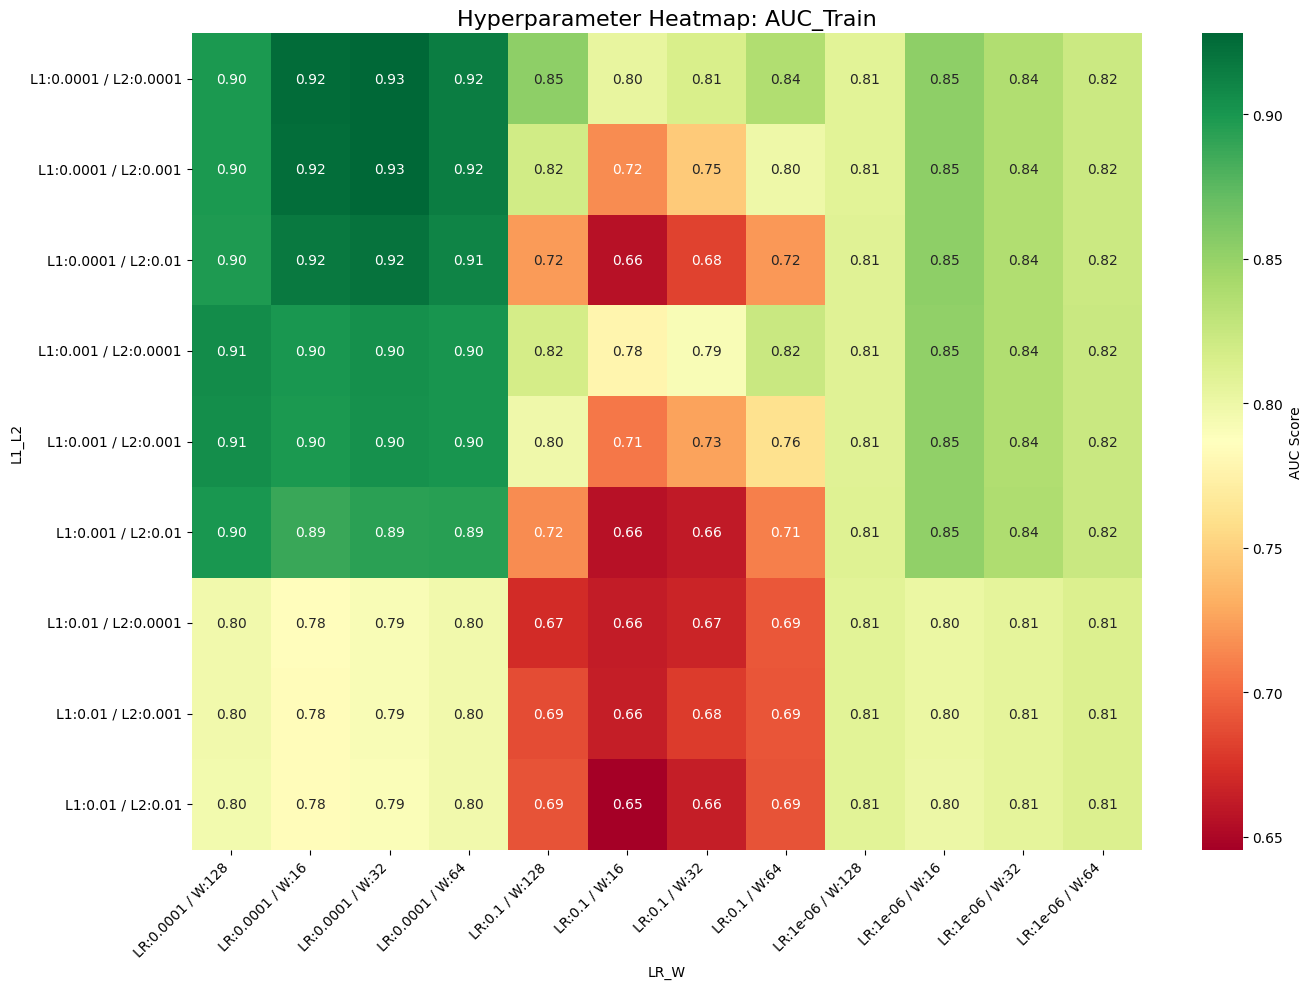

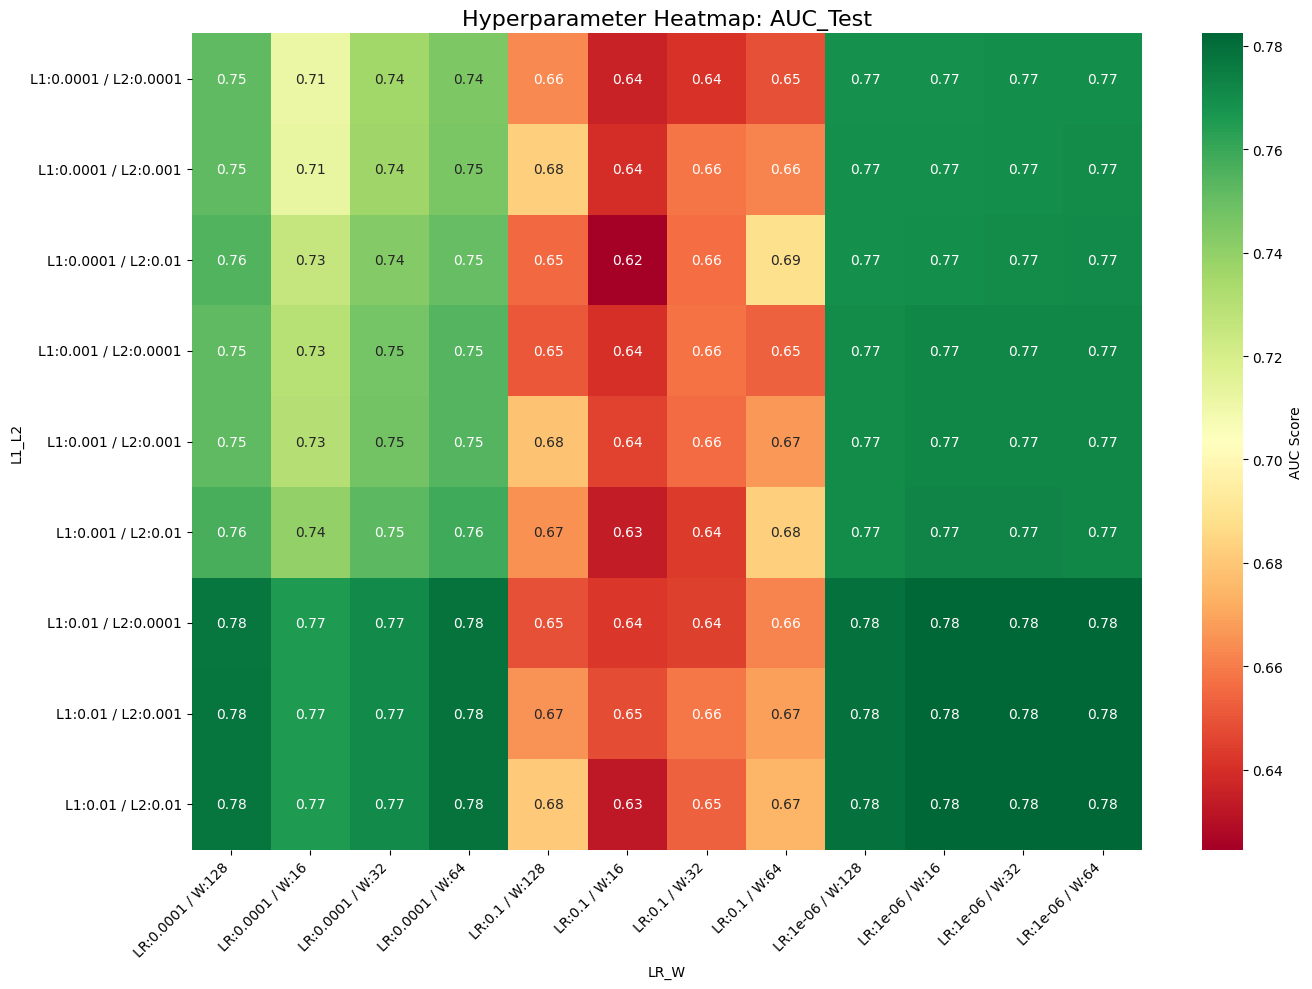

In [11]:
df_params = pd.DataFrame(df['Parameters'].to_list(), 
                         columns=['L1', 'L2', 'LR', 'Window'])


df_plot = pd.concat([df_params, df[['AUC_Train', 'AUC_Test']]], axis=1)
df_plot['L1_L2'] = "L1:" + df_plot['L1'].astype(str) + " / L2:" + df_plot['L2'].astype(str)
df_plot['LR_W'] = "LR:" + df_plot['LR'].astype(str) + " / W:" + df_plot['Window'].astype(str)


def plot_heatmaps(df, metric):
    pivot = df.pivot_table(index='L1_L2', columns='LR_W', values=metric)
    
    plt.figure(figsize=(14, 10))
    sns.heatmap(pivot, annot=True, cmap='RdYlGn', fmt=".2f", cbar_kws={'label': 'AUC Score'})
    plt.title(f'Hyperparameter Heatmap: {metric}', fontsize=16)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# 4. Generar los dos mapas
plot_heatmaps(df_plot, 'AUC_Train')
plot_heatmaps(df_plot, 'AUC_Test')

## Modelo Noche

In [2]:
df = pd.DataFrame({
'Parameters': [[0.01, 0.01, 1e-06, 64], [0.01, 0.01, 1e-06, 32], [0.01, 0.01, 1e-06, 16], [0.01, 0.01, 1e-06, 128], [0.01, 0.01, 0.1, 64], [0.01, 0.01, 0.1, 32], [0.01, 0.01, 0.1, 16], [0.01, 0.01, 0.1, 128], [0.01, 0.01, 0.0001, 64], [0.01, 0.01, 0.0001, 32], [0.01, 0.01, 0.0001, 16], [0.01, 0.01, 0.0001, 128], [0.01, 0.001, 1e-06, 64], [0.01, 0.001, 1e-06, 32], [0.01, 0.001, 1e-06, 16], [0.01, 0.001, 1e-06, 128], [0.01, 0.001, 0.1, 64], [0.01, 0.001, 0.1, 32], [0.01, 0.001, 0.1, 16], [0.01, 0.001, 0.1, 128], [0.01, 0.001, 0.0001, 64], [0.01, 0.001, 0.0001, 32], [0.01, 0.001, 0.0001, 16], [0.01, 0.001, 0.0001, 128], [0.01, 0.0001, 1e-06, 64], [0.01, 0.0001, 1e-06, 32], [0.01, 0.0001, 1e-06, 16], [0.01, 0.0001, 1e-06, 128], [0.01, 0.0001, 0.1, 64], [0.01, 0.0001, 0.1, 32], [0.01, 0.0001, 0.1, 16], [0.01, 0.0001, 0.1, 128], [0.01, 0.0001, 0.0001, 64], [0.01, 0.0001, 0.0001, 32], [0.01, 0.0001, 0.0001, 16], [0.01, 0.0001, 0.0001, 128], [0.001, 0.01, 1e-06, 64], [0.001, 0.01, 1e-06, 32], [0.001, 0.01, 1e-06, 16], [0.001, 0.01, 1e-06, 128], [0.001, 0.01, 0.1, 64], [0.001, 0.01, 0.1, 32], [0.001, 0.01, 0.1, 16], [0.001, 0.01, 0.1, 128], [0.001, 0.01, 0.0001, 64], [0.001, 0.01, 0.0001, 32], [0.001, 0.01, 0.0001, 16], [0.001, 0.01, 0.0001, 128], [0.001, 0.001, 1e-06, 64], [0.001, 0.001, 1e-06, 32], [0.001, 0.001, 1e-06, 16], [0.001, 0.001, 1e-06, 128], [0.001, 0.001, 0.1, 64], [0.001, 0.001, 0.1, 32], [0.001, 0.001, 0.1, 16], [0.001, 0.001, 0.1, 128], [0.001, 0.001, 0.0001, 64], [0.001, 0.001, 0.0001, 32], [0.001, 0.001, 0.0001, 16], [0.001, 0.001, 0.0001, 128], [0.001, 0.0001, 1e-06, 64], [0.001, 0.0001, 1e-06, 32], [0.001, 0.0001, 1e-06, 16], [0.001, 0.0001, 1e-06, 128], [0.001, 0.0001, 0.1, 64], [0.001, 0.0001, 0.1, 32], [0.001, 0.0001, 0.1, 16], [0.001, 0.0001, 0.1, 128], [0.001, 0.0001, 0.0001, 64], [0.001, 0.0001, 0.0001, 32], [0.001, 0.0001, 0.0001, 16], [0.001, 0.0001, 0.0001, 128], [0.0001, 0.01, 1e-06, 64], [0.0001, 0.01, 1e-06, 32], [0.0001, 0.01, 1e-06, 16], [0.0001, 0.01, 1e-06, 128], [0.0001, 0.01, 0.1, 64], [0.0001, 0.01, 0.1, 32], [0.0001, 0.01, 0.1, 16], [0.0001, 0.01, 0.1, 128], [0.0001, 0.01, 0.0001, 64], [0.0001, 0.01, 0.0001, 32], [0.0001, 0.01, 0.0001, 16], [0.0001, 0.01, 0.0001, 128], [0.0001, 0.001, 1e-06, 64], [0.0001, 0.001, 1e-06, 32], [0.0001, 0.001, 1e-06, 16], [0.0001, 0.001, 1e-06, 128], [0.0001, 0.001, 0.1, 64], [0.0001, 0.001, 0.1, 32], [0.0001, 0.001, 0.1, 16], [0.0001, 0.001, 0.1, 128], [0.0001, 0.001, 0.0001, 64], [0.0001, 0.001, 0.0001, 32], [0.0001, 0.001, 0.0001, 16], [0.0001, 0.001, 0.0001, 128], [0.0001, 0.0001, 1e-06, 64], [0.0001, 0.0001, 1e-06, 32], [0.0001, 0.0001, 1e-06, 16], [0.0001, 0.0001, 1e-06, 128], [0.0001, 0.0001, 0.1, 64], [0.0001, 0.0001, 0.1, 32], [0.0001, 0.0001, 0.1, 16], [0.0001, 0.0001, 0.1, 128], [0.0001, 0.0001, 0.0001, 64], [0.0001, 0.0001, 0.0001, 32], [0.0001, 0.0001, 0.0001, 16], [0.0001, 0.0001, 0.0001, 128] ],
'AUC_Train':[0.668329, 0.689529, 0.693187, 0.646421, 0.545566, 0.543974, 0.536512, 0.55409, 0.643242, 0.619256, 0.631822, 0.640315, 0.668303, 0.689925, 0.69468, 0.64637, 0.55915, 0.554592, 0.561686, 0.569305, 0.644696, 0.621363, 0.634468, 0.64189, 0.668302, 0.689962, 0.69483, 0.646364, 0.574515, 0.5659, 0.576536, 0.604056, 0.644849, 0.621584, 0.634744, 0.642067, 0.667609, 0.699223, 0.731893, 0.644957, 0.599875, 0.566448, 0.549277, 0.628448, 0.822884, 0.832391, 0.828848, 0.812134, 0.667194, 0.698727, 0.729859, 0.644618, 0.726349, 0.69318, 0.66656, 0.774937, 0.825565, 0.838321, 0.835085, 0.813905, 0.667147, 0.698677, 0.729272, 0.644583, 0.746919, 0.740325, 0.743936, 0.774936, 0.825798, 0.838845, 0.835647, 0.814069, 0.650773, 0.664814, 0.669698, 0.635094, 0.589845, 0.571786, 0.567142, 0.64475, 0.832826, 0.848505, 0.84926, 0.817699, 0.645794, 0.656109, 0.659742, 0.633285, 0.741714, 0.698534, 0.690964, 0.795455, 0.83486, 0.851247, 0.852183, 0.818545, 0.645421, 0.655631, 0.659125, 0.633151, 0.76959, 0.768667, 0.747285, 0.780174, 0.835025, 0.851506, 0.852395, 0.818608 ],
'AUC_Test':[0.570476, 0.57403, 0.576097, 0.56672, 0.523159, 0.526673, 0.518988, 0.50816, 0.573958, 0.556396, 0.560528, 0.559645, 0.570278, 0.573962, 0.575802, 0.566564, 0.524501, 0.513325, 0.544239, 0.531978, 0.573795, 0.55644, 0.560058, 0.559503, 0.570248, 0.573965, 0.57576, 0.566535, 0.514051, 0.517796, 0.518225, 0.540775, 0.573804, 0.55645, 0.560004, 0.559394, 0.560694, 0.563313, 0.564713, 0.558383, 0.526671, 0.513151, 0.516968, 0.516165, 0.558793, 0.548186, 0.535786, 0.556026, 0.560442, 0.563008, 0.564164, 0.558152, 0.549579, 0.506208, 0.525476, 0.529784, 0.557799, 0.547401, 0.533612, 0.555876, 0.560398, 0.56294, 0.564087, 0.55814, 0.519494, 0.513055, 0.517606, 0.529805, 0.557694, 0.547294, 0.533419, 0.555856, 0.556205, 0.556508, 0.55684, 0.555562, 0.52168, 0.520109, 0.53303, 0.515096, 0.556468, 0.547942, 0.534689, 0.555455, 0.555404, 0.555365, 0.555895, 0.554955, 0.54446, 0.522746, 0.525544, 0.537377, 0.555614, 0.54735, 0.532165, 0.555151, 0.555324, 0.555337, 0.555856, 0.554927, 0.509359, 0.524458, 0.529842, 0.537227, 0.555446, 0.547215, 0.531851, 0.555062 ]
})

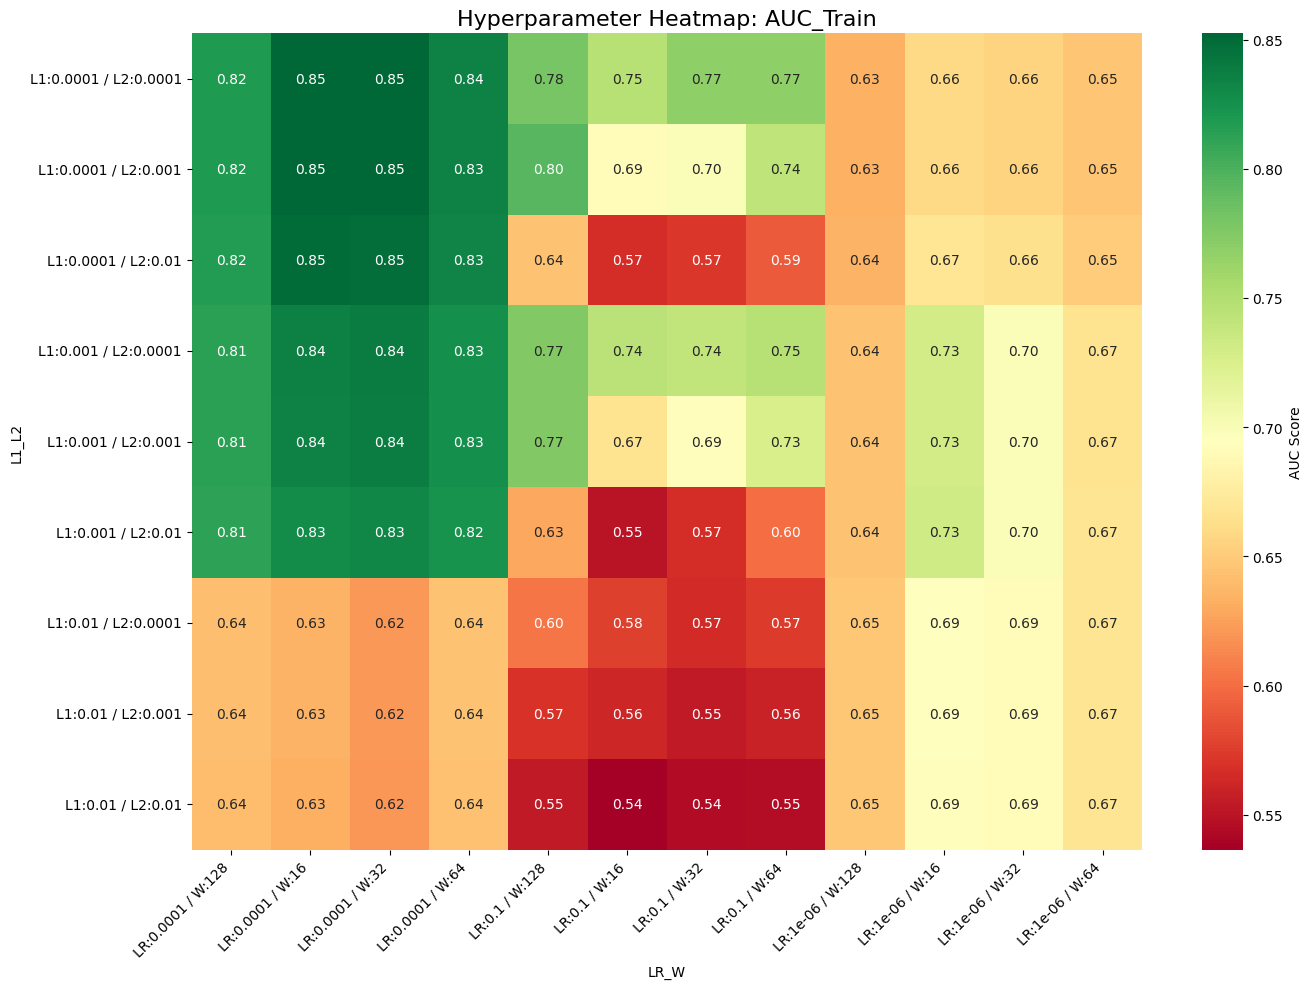

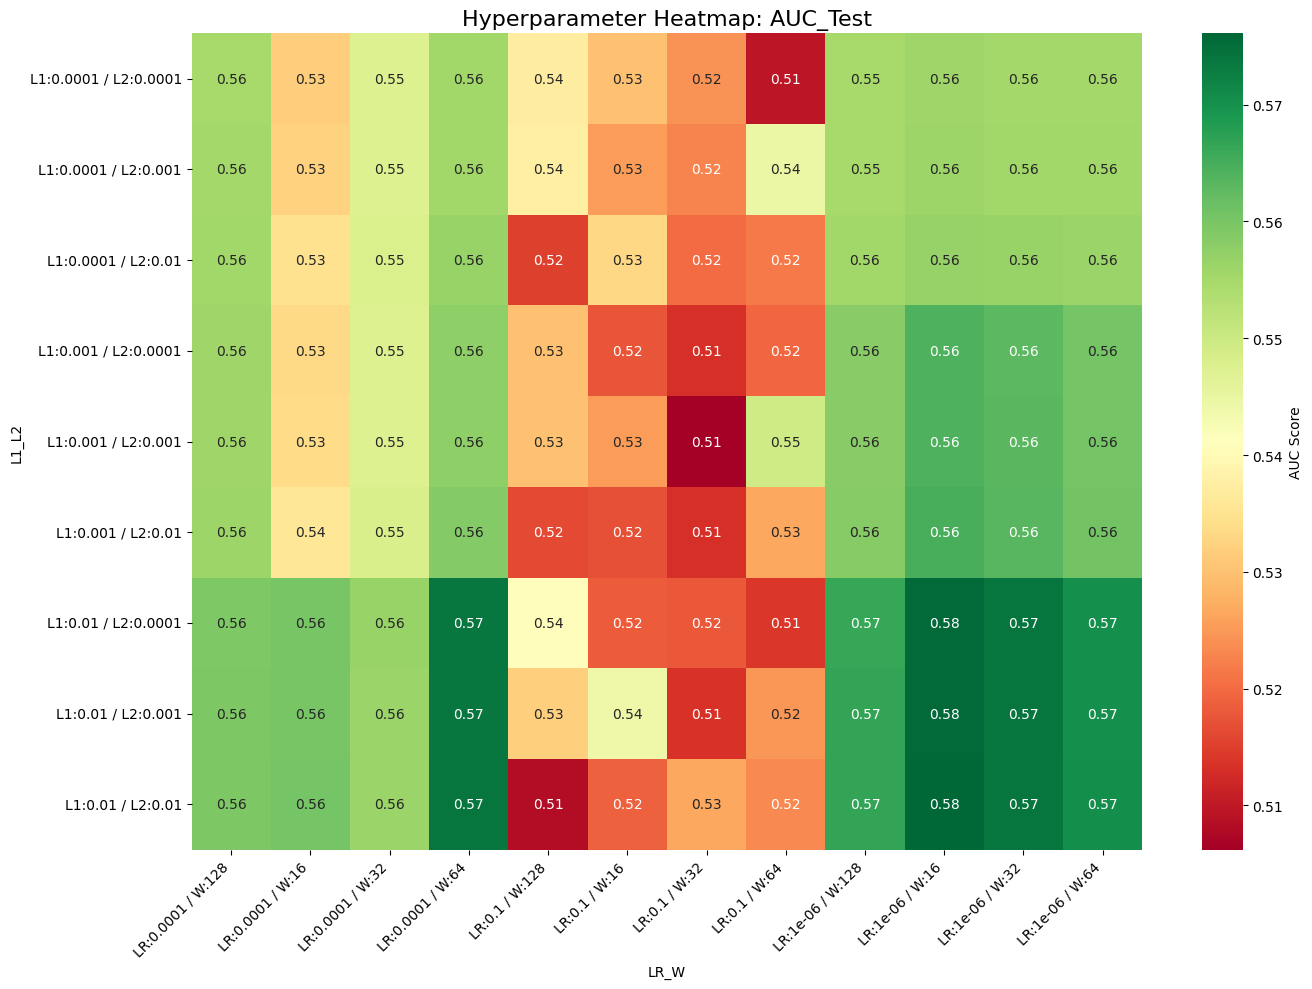

In [5]:
df_params = pd.DataFrame(df['Parameters'].to_list(), 
                         columns=['L1', 'L2', 'LR', 'Window'])


df_plot = pd.concat([df_params, df[['AUC_Train', 'AUC_Test']]], axis=1)
df_plot['L1_L2'] = "L1:" + df_plot['L1'].astype(str) + " / L2:" + df_plot['L2'].astype(str)
df_plot['LR_W'] = "LR:" + df_plot['LR'].astype(str) + " / W:" + df_plot['Window'].astype(str)


def plot_heatmaps(df, metric):
    pivot = df.pivot_table(index='L1_L2', columns='LR_W', values=metric)
    
    plt.figure(figsize=(14, 10))
    sns.heatmap(pivot, annot=True, cmap='RdYlGn', fmt=".2f", cbar_kws={'label': 'AUC Score'})
    plt.title(f'Hyperparameter Heatmap: {metric}', fontsize=16)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# 4. Generar los dos mapas
plot_heatmaps(df_plot, 'AUC_Train')
plot_heatmaps(df_plot, 'AUC_Test')